In [6]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

honda = pd.read_csv(r"C:\Users\alina\OneDrive\Desktop\EDA\honda_50.csv")
yamaha = pd.read_csv(r"C:\Users\alina\OneDrive\Desktop\EDA\yamaha_50.csv")
print(honda.head())
print(yamaha.head())

         bike_name  engine_cc  mileage_kmpl  price_lakh  top_speed_kmph  \
0       Honda SP 0        180          71.5        3.41             103   
1       Honda CB 1        160          69.0        2.91             155   
2  Honda Unicorn 2        200          64.6        1.72             119   
3       Honda CB 3        350          52.9        0.82             114   
4    Honda Shine 4        250          30.2        2.91             163   

   weight_kg  launch_year  rating  
0        108         2024     4.6  
1        145         2023     4.3  
2        131         2015     4.7  
3        129         2018     3.9  
4        157         2024     4.6  
        bike_name  engine_cc  mileage_kmpl  price_lakh  top_speed_kmph  \
0     Yamaha RX 0        200          63.0        1.21             177   
1    Yamaha R15 1        180          46.4        2.54             110   
2  Yamaha Fazer 2        160          36.6        0.84             109   
3    Yamaha R15 3        110         

In [7]:
honda['Company'] = 'Honda'
yamaha['Company'] = 'Yamaha'
df = pd.concat([honda, yamaha], ignore_index=True)
print(df.shape)
print(df.info())

(100, 9)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   bike_name       100 non-null    object 
 1   engine_cc       100 non-null    int64  
 2   mileage_kmpl    100 non-null    float64
 3   price_lakh      100 non-null    float64
 4   top_speed_kmph  100 non-null    int64  
 5   weight_kg       100 non-null    int64  
 6   launch_year     100 non-null    int64  
 7   rating          100 non-null    float64
 8   Company         100 non-null    object 
dtypes: float64(3), int64(4), object(2)
memory usage: 7.2+ KB
None


In [8]:
print(df.isnull().sum())
df = df.dropna()
print(df.describe())

bike_name         0
engine_cc         0
mileage_kmpl      0
price_lakh        0
top_speed_kmph    0
weight_kg         0
launch_year       0
rating            0
Company           0
dtype: int64
       engine_cc  mileage_kmpl  price_lakh  top_speed_kmph   weight_kg  \
count  100.00000    100.000000  100.000000      100.000000  100.000000   
mean   203.40000     53.571000    2.098400      130.550000  147.970000   
std     78.78458     13.546495    0.838495       25.783236   26.149707   
min    110.00000     30.200000    0.740000       90.000000  100.000000   
25%    150.00000     40.800000    1.350000      108.750000  129.000000   
50%    180.00000     55.450000    2.125000      125.500000  147.500000   
75%    250.00000     65.600000    2.842500      152.500000  173.000000   
max    350.00000     74.700000    3.460000      180.000000  190.000000   

       launch_year      rating  
count   100.000000  100.000000  
mean   2019.820000    4.225000  
std       2.833351    0.445261  
min    2

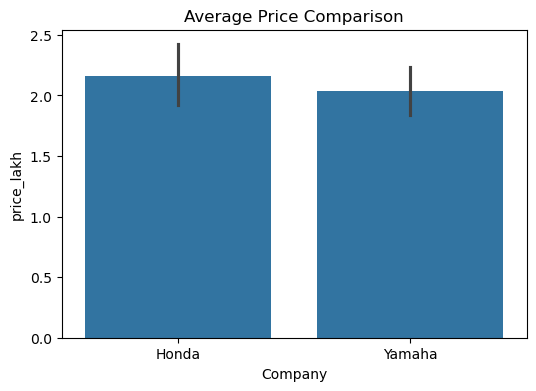

In [9]:
plt.figure(figsize=(6,4))
sns.barplot(x='Company', y='price_lakh', data=df)
plt.title("Average Price Comparison")
plt.show()

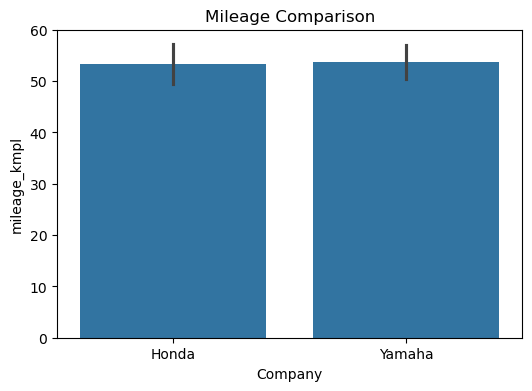

In [10]:
plt.figure(figsize=(6,4))
sns.barplot(x='Company', y='mileage_kmpl', data=df)
plt.title("Mileage Comparison")
plt.show()

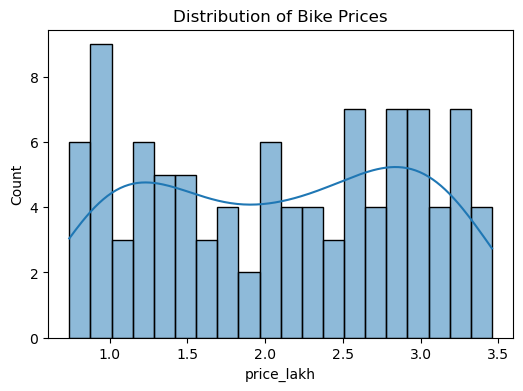

In [11]:
plt.figure(figsize=(6,4))
sns.histplot(df['price_lakh'], bins=20, kde=True)
plt.title("Distribution of Bike Prices")
plt.show()

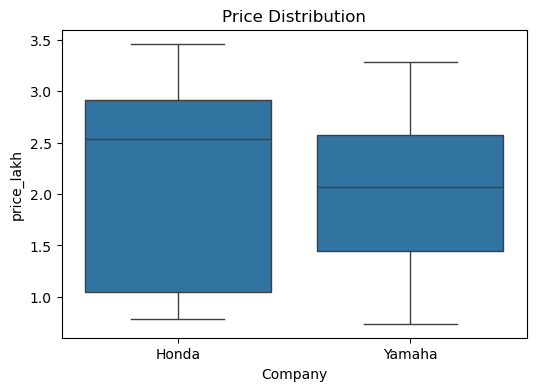

In [12]:
plt.figure(figsize=(6,4))
sns.boxplot(x='Company', y='price_lakh', data=df)
plt.title("Price Distribution")
plt.show()

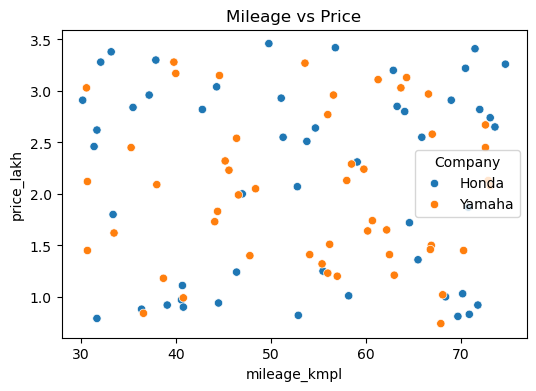

In [13]:
plt.figure(figsize=(6,4))
sns.scatterplot(x='mileage_kmpl', y='price_lakh', hue='Company', data=df)
plt.title("Mileage vs Price")
plt.show()

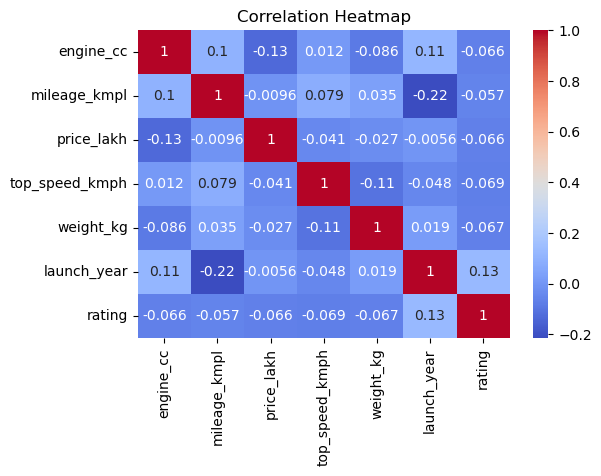

In [14]:
numeric_df = df.select_dtypes(include=['number'])
plt.figure(figsize=(6,4))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

In [15]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['Company_encoded'] = le.fit_transform(df['Company'])

X = df[['engine_cc', 'mileage_kmpl', 'price_lakh', 'top_speed_kmph', 'weight_kg']]
y = df['rating']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

lr = LinearRegression()
lr.fit(X_train, y_train)
print("Linear Regression Score:", lr.score(X_test, y_test))

dt = DecisionTreeRegressor()
dt.fit(X_train, y_train)
print("Decision Tree Score:", dt.score(X_test, y_test))

rf = RandomForestRegressor()
rf.fit(X_train, y_train)
print("Random Forest Score:", rf.score(X_test, y_test))

Linear Regression Score: -0.365943553605921
Decision Tree Score: -0.8736951983298538
Random Forest Score: -0.42173616910229694


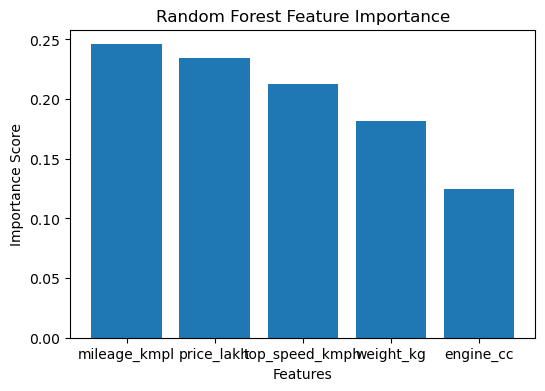

In [16]:
importance = rf.feature_importances_
features = X.columns
imp_df = pd.DataFrame({'Feature': features, 'Importance': importance})
imp_df = imp_df.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(6,4))
plt.bar(imp_df['Feature'], imp_df['Importance'])
plt.title("Random Forest Feature Importance")
plt.xlabel("Features")
plt.ylabel("Importance Score")
plt.show()